# Monte Carlo Terminal-Value Distributions and Tail Risk

**Question this notebook asks:** when you estimate the tail risk of an equity index
over a fixed horizon, how much of the answer comes from the data and how much comes
from the distribution you assumed?

Every other notebook in this repository starts from a parametric stochastic
differential equation (geometric Brownian motion, Ornstein-Uhlenbeck, Heston, Bates,
Merton jump-diffusion, SABR) and works out its consequences. This notebook runs the
comparison in the opposite direction. It holds the underlying, the horizon, and the
quantity of interest fixed, and varies **only** the assumed distribution of daily
returns:

| Generator | Assumption | What it is sensitive to |
|---|---|---|
| Historical bootstrap | returns are i.i.d. draws from the empirical sample | the realised sample, including its actual crash days |
| Lognormal (GBM) | log returns are i.i.d. $\mathcal{N}(m, s^2)$ | the first two moments only |
| Student-$t$ | log returns are i.i.d. scaled $t_\nu$, variance matched to the sample | the same two moments, plus a chosen tail index $\nu$ |

All three are deliberately **i.i.d.**: none of them model volatility clustering. That
is the single largest limitation of the exercise and is discussed at the end.

## Risk measures: definitions

Define the horizon loss as a fraction of the starting level,

$$L \;=\; -\left(\frac{S_T}{S_0} - 1\right).$$

Value at Risk and Expected Shortfall at confidence level $\alpha$ are then

$$\mathrm{VaR}_\alpha \;=\; F_L^{-1}(\alpha), \qquad
\mathrm{ES}_\alpha \;=\; \mathbb{E}\!\left[\,L \;\middle|\; L \ge \mathrm{VaR}_\alpha\,\right].$$

$\mathrm{VaR}_\alpha$ is the loss that is exceeded with probability $1-\alpha$;
$\mathrm{ES}_\alpha$ is the average loss *conditional on* exceeding it. ES is reported
alongside VaR throughout because VaR says nothing about the shape of the tail beyond
the quantile, and the shape of the tail is exactly what distinguishes the three
generators.

## Setup

**Reproducibility:** this notebook is seeded, so re-running it reproduces the figures
exactly. A seed fixes the sample rather than the conclusion, so any claim made here
should hold across seeds rather than only at this one. Note also that NumPy guarantees
the `default_rng` stream for a given version rather than indefinitely, which is part of
why `requirements.txt` is pinned.

In [1]:
from __future__ import annotations

import pathlib
import sys
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Walk up to the repository root (the directory containing `src/`) so this
# notebook imports the same way regardless of how deeply it is nested.
REPO_ROOT = next(p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]
                 if (p / "src").is_dir())
sys.path.append(str(REPO_ROOT))

from src.data import load_prices, simple_returns

In [2]:
# --- Configuration -----------------------------------------------------------
TICKER = "^SPX"
HORIZON_DAYS = 94          # trading days; roughly one calendar quarter plus a month
N_SIMS = 25_000
T_DOF = 4                  # Student-t degrees of freedom; lower = heavier tails
CONFIDENCE_LEVELS = (0.95, 0.99)
SEED = 20260913

rng = np.random.default_rng(SEED)

# --- Plot styling ------------------------------------------------------------
# Categorical slots 1-3 of the repository palette. These three validate as an
# all-pairs colour-vision-deficiency-safe set, which matters here because the
# three densities are overlaid on shared axes rather than shown as small multiples.
COLORS = {"Bootstrap": "#2a78d6", "Lognormal": "#eb6834", f"Student-t (v={T_DOF})": "#1baf7a"}
INK, MUTED = "#0b0b0b", "#52514e"

plt.rcParams.update({
    "figure.dpi": 110,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.edgecolor": MUTED,
    "axes.labelcolor": INK,
    "text.color": INK,
    "xtick.color": MUTED,
    "ytick.color": MUTED,
    "grid.color": "#e6e5e1",
    "grid.linewidth": 0.8,
    "legend.frameon": False,
    "font.size": 10,
})

## Data

`load_prices` caches the downloaded series to `data/` on first use and reads from that
cache afterwards, so this notebook re-executes deterministically and without a network
connection once it has been run once. Pass `refresh=True` to pull a fresh series.

In [3]:
prices = load_prices(TICKER, period="max", interval="1d")
returns = simple_returns(prices)
spot = float(prices.iloc[-1])

print(f"{TICKER}: {len(prices):,} daily closes, "
      f"{prices.index[0]:%Y-%m-%d} to {prices.index[-1]:%Y-%m-%d}")
print(f"Last close                 : {spot:,.2f}")
print(f"Mean daily simple return   : {returns.mean():.6f}")
print(f"Std  daily simple return   : {returns.std(ddof=1):.6f}")
print(f"Annualised volatility      : {returns.std(ddof=1) * np.sqrt(252):.2%}")
print(f"Excess kurtosis (daily)    : {returns.kurt():.2f}")

^SPX: 24,791 daily closes, 1927-12-30 to 2026-09-11
Last close                 : 7,656.98
Mean daily simple return   : 0.000316
Std  daily simple return   : 0.011910
Annualised volatility      : 18.91%
Excess kurtosis (daily)    : 17.28


The excess kurtosis printed above is the motivation for the whole notebook: a normal
distribution has excess kurtosis $0$, and daily equity index returns do not come close.
Any risk number produced under a Gaussian assumption is therefore being produced by a
model the data has already rejected. The question is how much that costs.

## Return generators

Each generator takes the historical return sample and produces an array of $N$
simulated **terminal prices**. Keeping them behind a common signature makes the
comparison below a loop rather than three near-duplicate blocks.

In [4]:
def simulate_bootstrap(
    returns: np.ndarray,
    spot: float,
    horizon: int,
    n_sims: int,
    rng: np.random.Generator,
) -> np.ndarray:
    """Terminal prices under an i.i.d. bootstrap of historical simple returns.

    Imposes no parametric form at all: every simulated day is a day that actually
    happened, sampled with replacement. Tail behaviour is therefore inherited
    directly from the sample, but no return larger than the historical maximum can
    ever be drawn.
    """
    draws = rng.choice(returns, size=(n_sims, horizon), replace=True)
    return spot * np.prod(1.0 + draws, axis=1)


def simulate_lognormal(
    returns: np.ndarray,
    spot: float,
    horizon: int,
    n_sims: int,
    rng: np.random.Generator,
) -> np.ndarray:
    """Terminal prices under geometric Brownian motion.

    Log returns are drawn i.i.d. from N(m, s^2), with m and s estimated from the
    *log* returns of the sample. Estimating them from simple returns instead is a
    common slip: the parameters of a lognormal are the moments of the underlying
    normal, not of the gross return.
    """
    log_returns = np.log1p(returns)
    m, s = log_returns.mean(), log_returns.std(ddof=1)
    draws = rng.normal(loc=m, scale=s, size=(n_sims, horizon))
    return spot * np.exp(draws.sum(axis=1))


def simulate_student_t(
    returns: np.ndarray,
    spot: float,
    horizon: int,
    n_sims: int,
    rng: np.random.Generator,
    dof: int = T_DOF,
) -> np.ndarray:
    """Terminal prices under i.i.d. Student-t log returns, variance-matched.

    A standard t with nu degrees of freedom has variance nu / (nu - 2), not 1, so
    drawing t_nu(loc=m, scale=s) simulates at a volatility of s * sqrt(nu / (nu - 2)) --
    41% too high at nu = 4. Dividing the scale by that factor makes the simulated
    variance match the sample, which is what makes the comparison against the
    lognormal case a comparison of *tail shape* rather than of volatility.
    """
    if dof <= 2:
        raise ValueError("Student-t variance is undefined for dof <= 2.")
    log_returns = np.log1p(returns)
    m, s = log_returns.mean(), log_returns.std(ddof=1)
    scale = s / np.sqrt(dof / (dof - 2.0))
    draws = m + scale * rng.standard_t(dof, size=(n_sims, horizon))
    return spot * np.exp(draws.sum(axis=1))

## Computing the risk measures

Both measures are computed on the simulated **loss** distribution, expressed as a
fraction of the starting level, so they are comparable across horizons and across
underlyings. Reporting VaR as a price level, which is the more natural thing to read
off a histogram, hides the fact that it is a loss statistic.

In [5]:
def risk_summary(
    terminal: np.ndarray,
    spot: float,
    levels: tuple[float, ...] = CONFIDENCE_LEVELS,
) -> dict[str, float]:
    """VaR and ES at each confidence level, as positive fractional losses."""
    loss = -(terminal / spot - 1.0)
    out: dict[str, float] = {
        "Median return": float(np.median(-loss)),
        "Mean return": float(np.mean(-loss)),
        "P(loss)": float(np.mean(loss > 0.0)),
    }
    for alpha in levels:
        var = float(np.quantile(loss, alpha))
        out[f"VaR {alpha:.0%}"] = var
        out[f"ES {alpha:.0%}"] = float(loss[loss >= var].mean())
    return out

In [6]:
generators = {
    "Bootstrap": simulate_bootstrap,
    "Lognormal": simulate_lognormal,
    f"Student-t (v={T_DOF})": simulate_student_t,
}

r = returns.to_numpy()
terminals = {
    name: fn(r, spot, HORIZON_DAYS, N_SIMS, np.random.default_rng(SEED))
    for name, fn in generators.items()
}

summary = pd.DataFrame(
    {name: risk_summary(t, spot) for name, t in terminals.items()}
).T

# Formatted as strings rather than via `.style`, which needs jinja2 and would put
# an extra dependency in the way of running this notebook.
summary.map("{:.2%}".format)


,Median return,Mean return,P(loss),VaR 95%,ES 95%,VaR 99%,ES 99%
Bootstrap,2.16%,2.85%,42.26%,15.53%,19.92%,23.01%,26.24%
Lognormal,2.26%,2.93%,42.25%,15.49%,19.62%,22.27%,25.00%
Student-t (v=4),2.46%,3.15%,41.50%,15.30%,19.27%,21.99%,25.09%


Each generator is given its own `default_rng(SEED)` rather than sharing one stream, so
the three sets of results are reproducible independently of the order they are run in.
Re-running any single cell reproduces its numbers exactly.

## Where the assumption shows up, and where it stops mattering

The three generators are matched on the first two moments of the daily log return, so
they differ only in the *shape* of the daily distribution. The two panels below show what
that difference is worth at two horizons: one day, and the full 94.

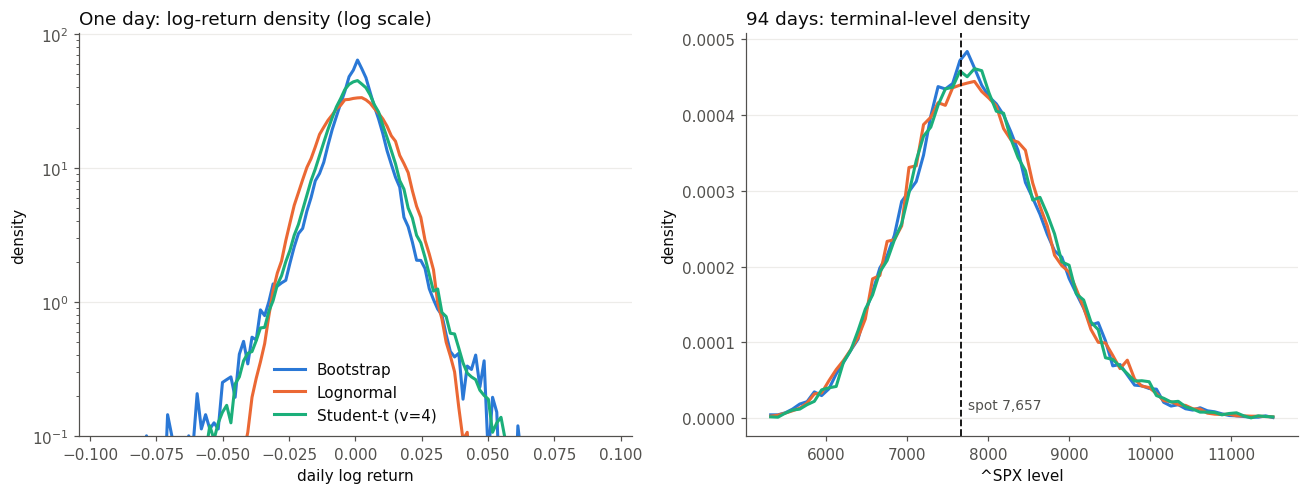

In [7]:
fig, (ax_day, ax_horizon) = plt.subplots(1, 2, figsize=(12, 4.6))

# --- Panel A: one-day log-return densities, log y-scale ----------------------
log_returns = np.log1p(r)
m, s = log_returns.mean(), log_returns.std(ddof=1)
scale_t = s / np.sqrt(T_DOF / (T_DOF - 2.0))
gen = np.random.default_rng(SEED)

daily = {
    "Bootstrap": np.log1p(gen.choice(r, size=N_SIMS * 4)),
    "Lognormal": gen.normal(m, s, size=N_SIMS * 4),
    f"Student-t (v={T_DOF})": m + scale_t * gen.standard_t(T_DOF, size=N_SIMS * 4),
}
day_edges = np.linspace(-8 * s, 8 * s, 121)
day_centres = 0.5 * (day_edges[:-1] + day_edges[1:])
for name, values in daily.items():
    density, _ = np.histogram(values, bins=day_edges, density=True)
    ax_day.plot(day_centres, density, color=COLORS[name], lw=2, label=name)
ax_day.set_yscale("log")
ax_day.set_ylim(1e-1, None)
ax_day.set_title("One day: log-return density (log scale)", loc="left")
ax_day.set_xlabel("daily log return")
ax_day.set_ylabel("density")
ax_day.legend(loc="lower center")

# --- Panel B: terminal levels after the full horizon -------------------------
pooled = np.concatenate(list(terminals.values()))
edges = np.linspace(np.quantile(pooled, 0.0005), np.quantile(pooled, 0.9995), 71)
centres = 0.5 * (edges[:-1] + edges[1:])
for name, values in terminals.items():
    density, _ = np.histogram(values, bins=edges, density=True)
    ax_horizon.plot(centres, density, color=COLORS[name], lw=2, label=name)
ax_horizon.axvline(spot, color=INK, lw=1.2, ls="--")
ax_horizon.annotate(f"spot {spot:,.0f}", xy=(spot, 0), xytext=(5, 6),
                    textcoords="offset points", color=MUTED, fontsize=9)
ax_horizon.set_title(f"{HORIZON_DAYS} days: terminal-level density", loc="left")
ax_horizon.set_xlabel(f"{TICKER} level")
ax_horizon.set_ylabel("density")

for ax in (ax_day, ax_horizon):
    ax.grid(axis="y", alpha=0.7)
    ax.set_axisbelow(True)

fig.tight_layout()
plt.show()

**Panel A: at the daily horizon the assumption is everything.** The log scale is what
makes this visible. The three densities agree through the body, where most of the
probability mass sits, and then separate by orders of magnitude in the wings. The
Gaussian case decays fastest; the Student-$t$ carries the most mass out at $\pm 5\sigma$
and beyond; the bootstrap sits in between, and is the only one of the three that stops
dead at the largest move in the historical sample. Same volatility, completely different
answers about how often a very bad day happens.

**Panel B: at 94 days most of that difference is gone.** This is the central limit
theorem doing its work. The terminal value is a product of 94 i.i.d. draws, so its
logarithm is a *sum* of 94 i.i.d. draws, and sums of i.i.d. variables with finite
variance converge to a normal regardless of what the summands looked like. The three
densities in the right panel are close to indistinguishable by eye. Every generator is
variance-matched, so they also agree on the width.

**So read the table, not the chart.** What survives the aggregation is small but not
zero, and it is concentrated where VaR does not look. Compare the `VaR 99%` and `ES 99%`
columns in the summary table above. The VaR figures are close across the three rows,
because the 99th percentile of the loss distribution is still well inside the region the
CLT has already smoothed. The ES figures spread further apart, because ES averages over
*everything* past the quantile, including the part of the tail that has not converged and
will not converge at this horizon.

That is the practical conclusion, and it is more useful than the one the exercise was set
up to find. The distributional assumption matters enormously for one-day risk and much
less for quarterly risk, and if you are going to report a single number at the longer
horizon, ES is the one that still carries information about which assumption you made.
The corollary is a warning: a daily VaR figure scaled to a quarterly one by $\sqrt{T}$
inherits none of this structure and should not be trusted.

## Vectorisation

The path-accumulation step is the only part of this notebook with a meaningful cost:
$N \times H = 25{,}000 \times 94$ multiplications per generator. Written as a Python
loop over simulation rows it runs at interpreter speed; written as a single NumPy
reduction over the horizon axis it runs in compiled code. The two are compared below on
identical draws, with the results checked for equality rather than assumed equal.

In [8]:
def terminal_loop(draws: np.ndarray) -> np.ndarray:
    """Accumulate each path in a Python loop (one `cumprod` call per simulation)."""
    return np.array([row.cumprod()[-1] for row in 1.0 + draws])


def terminal_vectorised(draws: np.ndarray) -> np.ndarray:
    """Accumulate every path at once with a single reduction over the horizon axis."""
    return np.prod(1.0 + draws, axis=1)


bench_draws = np.random.default_rng(SEED).choice(r, size=(N_SIMS, HORIZON_DAYS))

timings = {}
for label, fn in (("Python loop", terminal_loop), ("Vectorised", terminal_vectorised)):
    fn(bench_draws[:100])                      # warm-up, excluded from the timing
    start = time.perf_counter()
    result = fn(bench_draws)
    timings[label] = time.perf_counter() - start
    timings[f"_{label}"] = result

assert np.allclose(timings["_Python loop"], timings["_Vectorised"], rtol=1e-12, atol=0)

speedup = timings["Python loop"] / timings["Vectorised"]
print(f"Python loop : {timings['Python loop'] * 1e3:8.1f} ms")
print(f"Vectorised  : {timings['Vectorised'] * 1e3:8.1f} ms")
print(f"Speed-up    : {speedup:8.1f}x  (outputs identical to 1e-12 relative)")

Python loop :     21.4 ms
Vectorised  :      2.6 ms
Speed-up    :      8.3x  (outputs identical to 1e-12 relative)


The two implementations are numerically identical to floating-point tolerance, so the
speed-up is free. The gap widens with `N_SIMS`, because the per-row Python overhead is
paid $N$ times while the vectorised version pays it once.

Worth noting what this does *not* buy. The reduction is still $O(NH)$ work; NumPy only
removes the interpreter overhead around it. Genuinely reducing the work would mean
changing the algorithm, not the implementation: for a pure lognormal the terminal value
has a closed form and needs no path at all, since the sum of $H$ i.i.d. normals is one
normal with variance $H s^2$. The path-based version is kept here because the bootstrap
and Student-$t$ cases have no such shortcut, and because a common code path across all
three is what makes them comparable.

## Limitations

**Returns are assumed i.i.d.** None of the three generators produce volatility
clustering, and volatility clustering is the most robust stylised fact in daily equity
returns. In practice this causes the simulated distributions to *understate* the
probability of a large cumulative drawdown, because real large moves arrive in
consecutive clusters rather than scattered independently across the horizon. The
Heston and Bates notebooks in this repository address exactly this, from the parametric
side. A block bootstrap, which resamples contiguous runs of days rather than individual
days, would be the non-parametric fix and is the natural extension of this notebook.

**The bootstrap cannot exceed its own sample.** No simulated path contains a daily move
larger than the worst day in the historical record. For tail estimation at high
confidence this is a real ceiling, and it is the argument for the parametric
Student-$t$ case sitting alongside it rather than being replaced by it.

**$\nu = 4$ is asserted, not estimated.** The degrees-of-freedom parameter is set by
hand. Fitting it by maximum likelihood to the return sample, and reporting the fitted
value with a confidence interval, would make the Student-$t$ column an estimate rather
than an assumption.

**The horizon is arbitrary.** 94 trading days is a round-ish quarter and nothing more.
Risk measures scale non-trivially with horizon under any of these generators, so a
figure quoted at one horizon should not be rescaled by $\sqrt{T}$ to another without
checking.